# Modern Signal Analysis and Signal Processing · Homework Code (Python)

This notebook is a Python implementation of the original MATLAB code for audio signal analysis and music synthesis demonstrations.

Modified by Haozheng Ji (jihz2023@mail.sustech.edu.cn) on March 5, 2026.

## Reference Implementations

- **waudio.m** — Haoran Meng, Fengjiang Ju & Wenyue Xia (2023-02-14)
- **Canon.m** — Haoran Meng, Fengjiang Ju & Wenyue Xia (2023-02-14); Mijia Chai, Fuhua Zheng, Yuxing Pan (2024-02-21)
- **WuKong.m** — Haoran Meng (2025-02-23)

## Dependencies

- `numpy`
- `matplotlib`
- `scipy`
- `sounddevice`


In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import wavfile
from scipy import signal
import sounddevice as sd 

# Fundamental note generation
## "La" signal
- Sampling rate: 44100 Hz
- Duration: 2 seconds
- Amplitude envelope: sine function


In [2]:
Fs = 44100 # Sampling frequency
T = 1/Fs # Sampling Period
f0 = 440 # Frequency of la

t = np.arange(0,2,T) # time line
A0=0.3 # Amplitude

envelope=np.sin(np.pi*t/t[-1])
y=envelope*A0*np.sin(2*np.pi*f0*t)
# y=A0*np.sin(2*np.pi*f0*t) # without envelope

y_normalized=y/np.max(y)
sd.play(y_normalized,Fs)
sd.wait()
wavfile.write('La.wav', Fs, (y_normalized * 32767).astype(np.int16))

### Plot the waveform and Fourier transform spectrum of the La signal

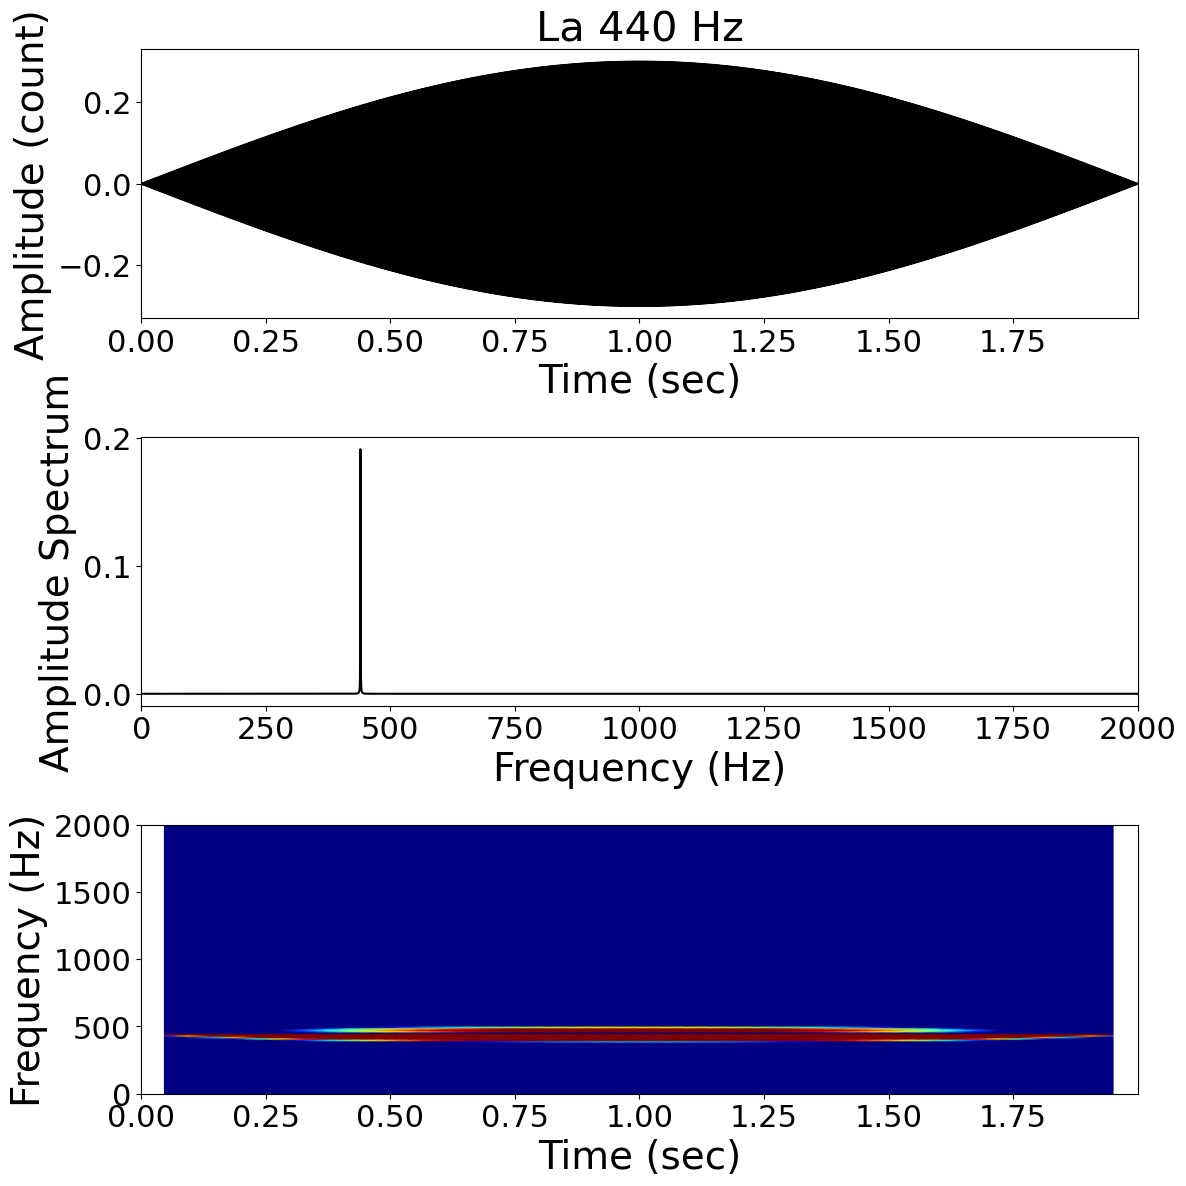

In [3]:
L=len(y)
f = Fs * np.arange(0,L//2+1,1)/L

Y=np.fft.fft(y) 
P2 = np.abs(Y/L) 
P1 = P2[:L//2+1]
P1[1:]=2*P1[1:]

fig,axes=plt.subplots(3,1,figsize=(12,12))
# Time domain signal
axes[0].plot(t,y,'k')
axes[0].set_xlim([0,t[-1]])
axes[0].set_xlabel('Time (sec)', fontsize=28)
axes[0].set_ylabel('Amplitude (count)', fontsize=28)
axes[0].set_title('La 440 Hz',fontsize=30)
axes[0].tick_params(labelsize=22)
# Amplitude Spectrum
axes[1].plot(f,P1,'k')
axes[1].set_xlim([0,2000])
axes[1].set_xlabel('Frequency (Hz)', fontsize=28)
axes[1].set_ylabel('Amplitude Spectrum', fontsize=28)
axes[1].tick_params(labelsize=22)
# Spectrogram
f_spec, t_spec, Sxx=signal.spectrogram(y,Fs,nperseg=4096,noverlap=2048,nfft=4096)
temp=np.log10(np.abs(Sxx))
im=axes[2].pcolormesh(t_spec,f_spec,temp,cmap='jet',vmin=np.min(temp)/5,vmax=np.max(temp)*2,shading='gouraud')
axes[2].set_ylabel('Frequency (Hz)',fontsize=28)
axes[2].set_xlabel('Time (sec)', fontsize=28)
axes[2].set_xlim([0,t[-1]])
axes[2].set_ylim([0,2000])
axes[2].tick_params(labelsize=22)
plt.tight_layout(pad=1.2, h_pad=1.8)
plt.savefig('./La.png',dpi=300)
plt.show()


## Musical scales
- Do Re Mi Fa So La Ti Do

In [ ]:
# idx=np.array([0,2,4,5,7,9,11,12]) 
idx=np.array([-9,-7,-5,-4,-2,0,2,3]) 

f00=f0*2**(idx/12) 
t=np.arange(0,8,T) 
y=np.zeros((len(t)))
for idx in range(len(f00)):
    t_start=idx*1
    t_end=t_start+1
    mask= (t>=t_start)&(t<t_end)
    y[mask]=A0*np.sin(2*np.pi*(f00[idx]*(t[mask]-t_start)))
plt.show() 
# add envelope 
envelope=np.sin(np.pi*8*t/t[-1])
y=envelope*y 
# y= 1 * y # without envelope
y_normalize=y/np.max(y)
sd.play(y,Fs)
sd.wait()
wavfile.write('./DoReMi.wav', Fs, (y_normalize * 32767).astype(np.int16))


### Plot the waveform and Fourier transform spectrum of the Musical Scales

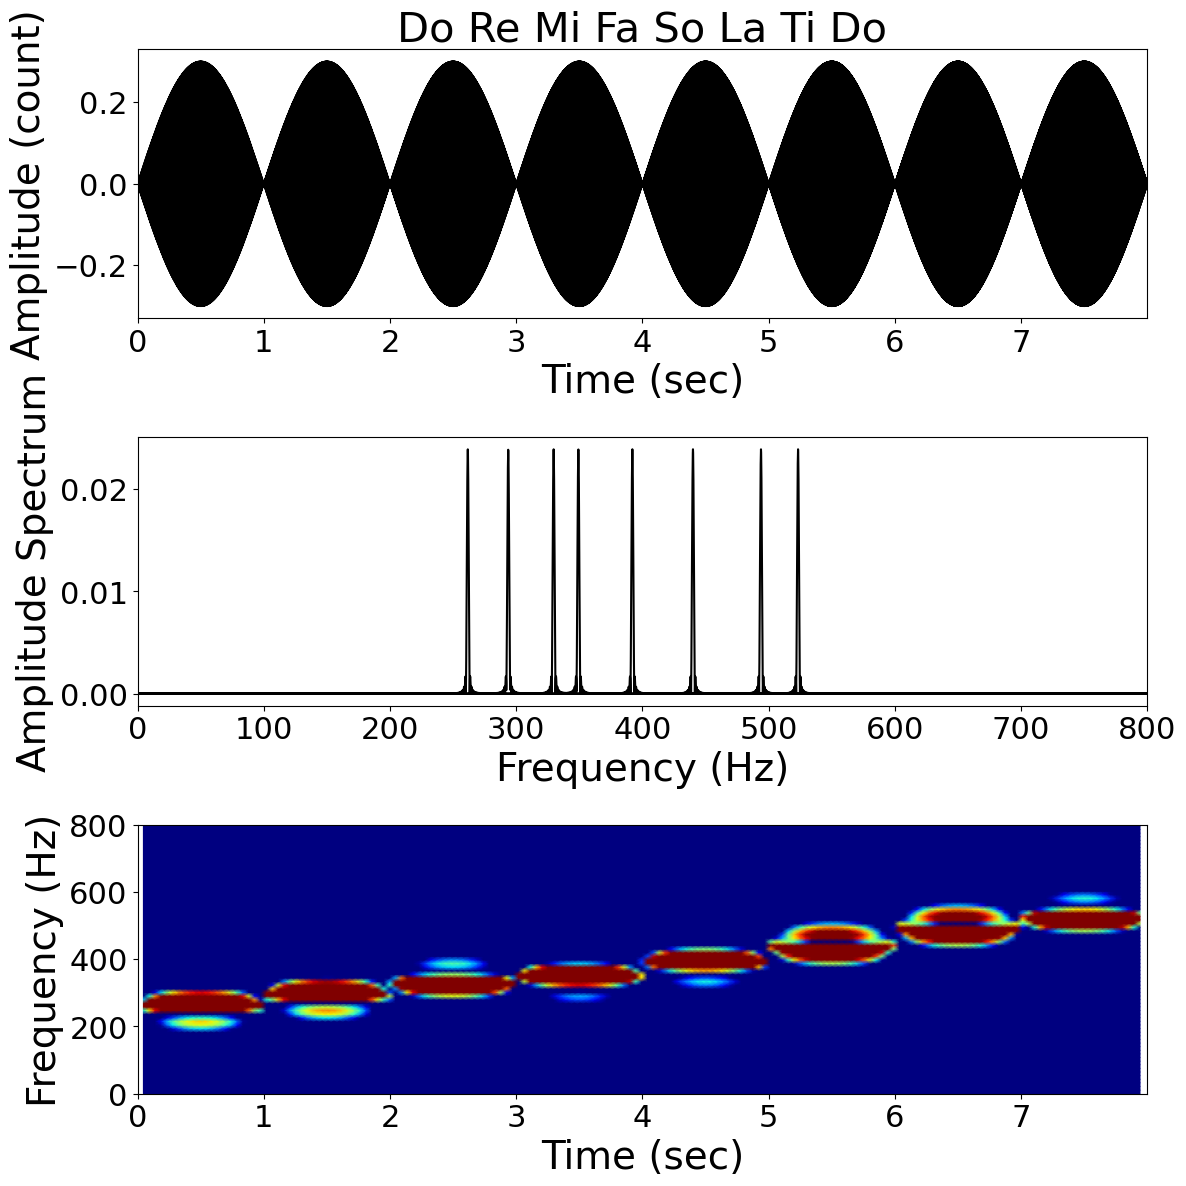

In [16]:
L=len(y)
f = Fs * np.arange(0,L//2+1,1)/L

Y=np.fft.fft(y) 
P2 = np.abs(Y/L) 
P1 = P2[:L//2+1]
P1[1:]=2*P1[1:]

fig,axes=plt.subplots(3,1,figsize=(12,12))
# Time domain signal
axes[0].plot(t,y,'k')
axes[0].set_xlim([0,t[-1]])
axes[0].set_xlabel('Time (sec)', fontsize=28)
axes[0].set_ylabel('Amplitude (count)', fontsize=28)
axes[0].set_title('Do Re Mi Fa So La Ti Do',fontsize=30)
axes[0].tick_params(labelsize=22)
# Amplitude Spectrum
axes[1].plot(f,P1,'k')
axes[1].set_xlim([0,800])
axes[1].set_xlabel('Frequency (Hz)', fontsize=28)
axes[1].set_ylabel('Amplitude Spectrum', fontsize=28)
axes[1].tick_params(labelsize=22)
# Spectrogram
f_spec, t_spec, Sxx=signal.spectrogram(y,Fs,nperseg=4096,noverlap=2048,nfft=4096)
temp=np.log10(np.abs(Sxx))
im=axes[2].pcolormesh(t_spec,f_spec,temp,cmap='jet',vmin=np.min(temp)/5,vmax=np.max(temp)*2,shading='gouraud')
axes[2].set_ylabel('Frequency (Hz)',fontsize=28)
axes[2].set_xlabel('Time (sec)', fontsize=28)
axes[2].set_xlim([0,t[-1]])
axes[2].set_ylim([0,800])
axes[2].tick_params(labelsize=22)
plt.tight_layout(pad=1.2, h_pad=1.8)
plt.savefig('./DoReMi.png',dpi=300)
plt.show()


# Music Signal Analysis
## Prepare the basic notes

In [17]:
T16=0.125
# t16=np.arange(0,T16,T)
# L=len(t16)
# print(L)
# envelope16=np.sin(np.pi*t16/t16[-1]) 
# T8=2*T16 
# t8=np.linspace(0,T8,2*L) 
# envelope8=np.sin(np.pi*t8/t8[-1])
# T4=4*T16 
# t4=np.linspace(0,T4,4*L) 
# envelope4=np.sin(np.pi*t4/t4[-1]) 

t16=np.arange(0,T16,T)
L=len(t16)
envelope16=np.sin(np.pi*t16/t16[-1]) 
T8=2*T16 
t8=np.arange(0,T8,T) 
envelope8=np.sin(np.pi*t8/t8[-1])
T4=4*T16 
t4=np.arange(0,T4,T) 
envelope4=np.sin(np.pi*t4/t4[-1]) 

f_standard=f00[1]
SacleTabel=np.array([2/3,3/4,5/6,15/16,
                     1,9/8,5/4,4/3,3/2,5/3,9/5,15/8,
                     2,9/4,5/2,8/3,3,10/3,15/4,
                     4,1/2,9/16,5/8]
                    )

do0f=envelope4*np.cos(2*np.pi*SacleTabel[20]*f_standard*t4)
re0f=envelope4*np.cos(2*np.pi*SacleTabel[21]*f_standard*t4)
mi0f=envelope4*np.cos(2*np.pi*SacleTabel[22]*f_standard*t4)
fa0f=envelope4*np.cos(2*np.pi*SacleTabel[0]*f_standard*t4)
so0f=envelope4*np.cos(2*np.pi*SacleTabel[1]*f_standard*t4)
la0f=envelope4*np.cos(2*np.pi*SacleTabel[2]*f_standard*t4)
ti0f=envelope4*np.cos(2*np.pi*SacleTabel[3]*f_standard*t4)
empf=do0f*0

do1f=envelope4*np.cos(2*np.pi*SacleTabel[4]*f_standard*t4)
re1f=envelope4*np.cos(2*np.pi*SacleTabel[5]*f_standard*t4)
mi1f=envelope4*np.cos(2*np.pi*SacleTabel[6]*f_standard*t4)
fa1f=envelope4*np.cos(2*np.pi*SacleTabel[7]*f_standard*t4)
so1f=envelope4*np.cos(2*np.pi*SacleTabel[8]*f_standard*t4)
la1f=envelope4*np.cos(2*np.pi*SacleTabel[9]*f_standard*t4)
tb1f=envelope4*np.cos(2*np.pi*SacleTabel[10]*f_standard*t4)
ti1f=envelope4*np.cos(2*np.pi*SacleTabel[11]*f_standard*t4)

do2f=envelope4*np.cos(2*np.pi*SacleTabel[12]*f_standard*t4)
re2f=envelope4*np.cos(2*np.pi*SacleTabel[13]*f_standard*t4)
mi2f=envelope4*np.cos(2*np.pi*SacleTabel[14]*f_standard*t4)
fa2f=envelope4*np.cos(2*np.pi*SacleTabel[15]*f_standard*t4)
so2f=envelope4*np.cos(2*np.pi*SacleTabel[16]*f_standard*t4)
la2f=envelope4*np.cos(2*np.pi*SacleTabel[17]*f_standard*t4)
tb2f=envelope4*np.cos(2*np.pi*SacleTabel[18]*f_standard*t4)
ti2f=envelope4*np.cos(2*np.pi*SacleTabel[19]*f_standard*t4)


do0e=envelope8*np.cos(2*np.pi*SacleTabel[20]*f_standard*t8)
re0e=envelope8*np.cos(2*np.pi*SacleTabel[21]*f_standard*t8)
mi0e=envelope8*np.cos(2*np.pi*SacleTabel[22]*f_standard*t8)
fa0e=envelope8*np.cos(2*np.pi*SacleTabel[0]*f_standard*t8)
so0e=envelope8*np.cos(2*np.pi*SacleTabel[1]*f_standard*t8)
la0e=envelope8*np.cos(2*np.pi*SacleTabel[2]*f_standard*t8)
ti0e=envelope8*np.cos(2*np.pi*SacleTabel[3]*f_standard*t8)

do1e=envelope8*np.cos(2*np.pi*SacleTabel[4]*f_standard*t8)
re1e=envelope8*np.cos(2*np.pi*SacleTabel[5]*f_standard*t8)
mi1e=envelope8*np.cos(2*np.pi*SacleTabel[6]*f_standard*t8)
fa1e=envelope8*np.cos(2*np.pi*SacleTabel[7]*f_standard*t8)
so1e=envelope8*np.cos(2*np.pi*SacleTabel[8]*f_standard*t8)
la1e=envelope8*np.cos(2*np.pi*SacleTabel[9]*f_standard*t8)
tb1e=envelope8*np.cos(2*np.pi*SacleTabel[10]*f_standard*t8)
ti1e=envelope8*np.cos(2*np.pi*SacleTabel[11]*f_standard*t8)

do2e=envelope8*np.cos(2*np.pi*SacleTabel[12]*f_standard*t8)
re2e=envelope8*np.cos(2*np.pi*SacleTabel[13]*f_standard*t8)
mi2e=envelope8*np.cos(2*np.pi*SacleTabel[14]*f_standard*t8)
fa2e=envelope8*np.cos(2*np.pi*SacleTabel[15]*f_standard*t8)
so2e=envelope8*np.cos(2*np.pi*SacleTabel[16]*f_standard*t8)
la2e=envelope8*np.cos(2*np.pi*SacleTabel[17]*f_standard*t8)
tb2e=envelope8*np.cos(2*np.pi*SacleTabel[18]*f_standard*t8)
ti2e=envelope8*np.cos(2*np.pi*SacleTabel[19]*f_standard*t8)
empe=do0e*0

do0s=envelope16*np.cos(2*np.pi*SacleTabel[20]*f_standard*t16)
re0s=envelope16*np.cos(2*np.pi*SacleTabel[21]*f_standard*t16)
mi0s=envelope16*np.cos(2*np.pi*SacleTabel[22]*f_standard*t16)
fa0s=envelope16*np.cos(2*np.pi*SacleTabel[0]*f_standard*t16)
so0s=envelope16*np.cos(2*np.pi*SacleTabel[1]*f_standard*t16)
la0s=envelope16*np.cos(2*np.pi*SacleTabel[2]*f_standard*t16)
ti0s=envelope16*np.cos(2*np.pi*SacleTabel[3]*f_standard*t16)

do1s=envelope16*np.cos(2*np.pi*SacleTabel[4]*f_standard*t16)
re1s=envelope16*np.cos(2*np.pi*SacleTabel[5]*f_standard*t16)
mi1s=envelope16*np.cos(2*np.pi*SacleTabel[6]*f_standard*t16)
fa1s=envelope16*np.cos(2*np.pi*SacleTabel[7]*f_standard*t16)
so1s=envelope16*np.cos(2*np.pi*SacleTabel[8]*f_standard*t16)
la1s=envelope16*np.cos(2*np.pi*SacleTabel[9]*f_standard*t16)
tb1s=envelope16*np.cos(2*np.pi*SacleTabel[10]*f_standard*t16)
ti1s=envelope16*np.cos(2*np.pi*SacleTabel[11]*f_standard*t16)

do2s=envelope16*np.cos(2*np.pi*SacleTabel[12]*f_standard*t16)
re2s=envelope16*np.cos(2*np.pi*SacleTabel[13]*f_standard*t16)
mi2s=envelope16*np.cos(2*np.pi*SacleTabel[14]*f_standard*t16)
fa2s=envelope16*np.cos(2*np.pi*SacleTabel[15]*f_standard*t16)
so2s=envelope16*np.cos(2*np.pi*SacleTabel[16]*f_standard*t16)
la2s=envelope16*np.cos(2*np.pi*SacleTabel[17]*f_standard*t16)
tb2s=envelope16*np.cos(2*np.pi*SacleTabel[18]*f_standard*t16)
ti2s=envelope16*np.cos(2*np.pi*SacleTabel[19]*f_standard*t16)


## Compose and Play Caron

In [18]:
y_canon=np.concatenate([so2e,mi2s,fa2s,so2e,mi2s,fa2s,so2s,so1s,la1s,ti1s,
do2s,re2s,mi2s,fa2s,mi2e,do2s,re2s,
mi2e,mi1s,fa1s,so1s,la1s,so1s,fa1s,so1s,mi1s,fa1s,so1s,
fa1e,la1s,so1s,fa1e,mi1s,re1s,mi1s,re1s,do1s,re1s,mi1s,fa1s,so1s,la1s,
fa2e,la1s,so1s,la1e,ti1s,do2s,so1s,la1s,ti1s,do2s,re2s,mi2s,fa2s,so2s,
so2e,mi2s,fa2s,so2e,mi2s,fa2s,so2s,so1s,la1s,ti1s,
do2s,re2s,mi2s,fa2s,mi2e,do2s,re2s,
mi2e,mi1s,fa1s,so1s,la1s,so1s,fa1s,so1s,mi1s,fa1s,so1s,
fa1e,la1s,so1s,fa1e,mi1s,re1s,mi1s,re1s,do1s,re1s,mi1s,fa1s,so1s,la1s,
fa2e,la1s,so1s,la1e,ti1s,do2s,so1s,la1s,ti1s,do2s,re2s,mi2s,fa2s,so2s,
])

y_canon_normalized=y_canon/np.max(y_canon)
sd.play(y_canon_normalized,Fs)
sd.wait()
wavfile.write('./Canon.wav',Fs,(y_canon_normalized*32767).astype(np.int16))


### Plot the waveform and Fourier transform spectrum of Canon

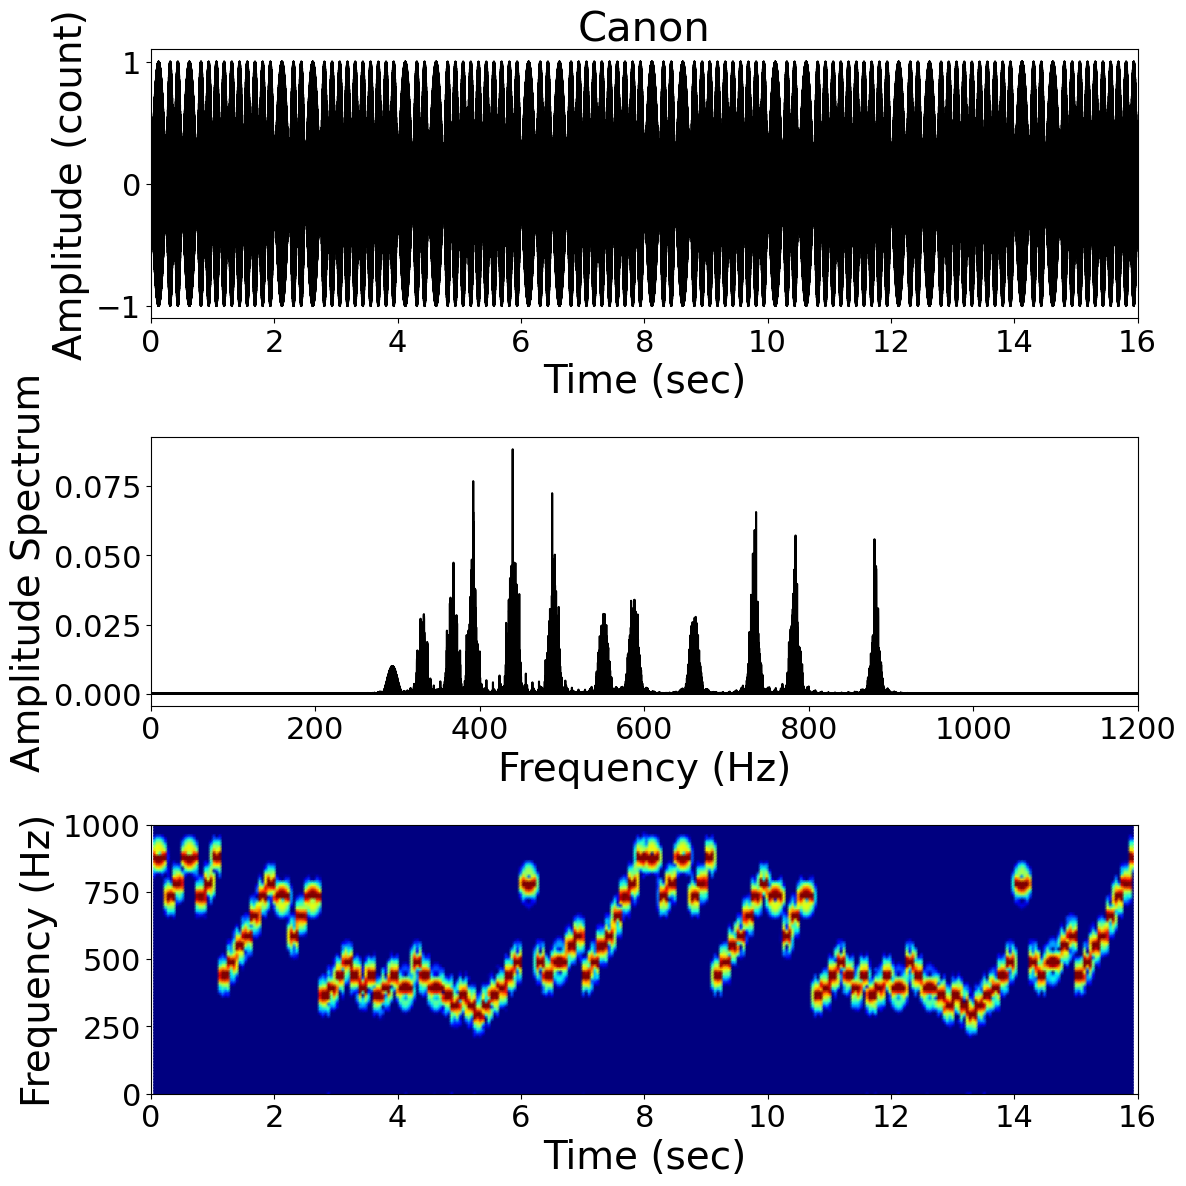

In [19]:
Y=np.fft.fft(y_canon)
N=len(y_canon)
t=T*np.arange(0,N,1)
f=Fs*np.arange(0,N//2+1,1)/N
P2 = np.abs(Y/N) 
P1 = P2[:N//2+1]
P1[1:]=2*P1[1:]

fig,axes=plt.subplots(3,1,figsize=(12,12))
# Time domain signal
axes[0].plot(t,y_canon,'k')
axes[0].set_xlim([0,t[-1]])
axes[0].set_xlabel('Time (sec)', fontsize=28)
axes[0].set_ylabel('Amplitude (count)', fontsize=28)
axes[0].set_title('Canon',fontsize=30)
axes[0].tick_params(labelsize=22)
# Amplitude Spectrum
axes[1].plot(f,P1,'k')
axes[1].set_xlim([0,1200])
axes[1].set_xlabel('Frequency (Hz)', fontsize=28)
axes[1].set_ylabel('Amplitude Spectrum', fontsize=28)
axes[1].tick_params(labelsize=22)
# Spectrogram
f_spec, t_spec, Sxx=signal.spectrogram(y_canon,Fs,nperseg=4096,noverlap=2048,nfft=4096)
temp=np.log10(np.abs(Sxx))
im=axes[2].pcolormesh(t_spec,f_spec,temp,cmap='jet',vmin=np.min(temp)/5,vmax=np.max(temp)*2,shading='gouraud')
axes[2].set_ylabel('Frequency (Hz)',fontsize=28)
axes[2].set_xlabel('Time (sec)', fontsize=28)
axes[2].set_xlim([0,t[-1]])
axes[2].set_ylim([0,1000])
axes[2].tick_params(labelsize=22)
plt.tight_layout(pad=1.2, h_pad=1.8)
plt.savefig('./Canon.png',dpi=300)
plt.show()

## Compose and Play Yun Gong Xun Yin

In [20]:
y_ygxy=np.concatenate([la0e,la0e,mi0e,la0e,do1e,la0e,mi0e,so0e,la0e,la0e,mi0e,la0e,do1e,la0e,mi0e,so0e,
                        la0e,la0e,mi0e,la0e,do1e,la0e,mi0e,so0e,la0e,la0e,mi0e,la0e,do1e,la0e,mi0e,so0e,
                        la0e,la0e,fa0e,so0e,do1e,la0e,fa0e,so0e,la0e,la0e,fa0e,so0e,do1e,la0e,fa0e,so0e,
                        la0e,la0e,fa0e,so0e,do1e,la0e,fa0e,so0e,la0e,la0e,fa0e,so0e,do1e,la0e,fa0e,so0e,
                        la0e,la0e,mi0e,la0e,do1e,la0e,la1e,do2e,la0e,la0e,mi0e,la0e,do1e,la0e,la1e,do2e,
                        re2f,re2f,empe,fa1e,la1e,do2e,re2f,re2f,do2f,re2f,fa2f,do2f,re2f,fa2f,mi2f,mi2f,empf,empf,
                        mi1f,empf,la1f,la1e,ti1e,do2f,la1f,fa2f,fa2e,re2e,mi2f,mi2f,empf,empf,
                        mi1f,empf,la1f,la1e,ti1e,do2f,la1f,fa2f,fa2e,mi2e,re2f,re2f,empf,empf
])

y_ygxy_normalized=y_ygxy/np.max(y_ygxy)
sd.play(y_ygxy_normalized,Fs)
sd.wait()
wavfile.write('./YunGongXunYin.wav',Fs,(y_ygxy_normalized*32767).astype(np.int16))

### Plot the waveform and Fourier transform spectrum of Yun Gong Xun Yin

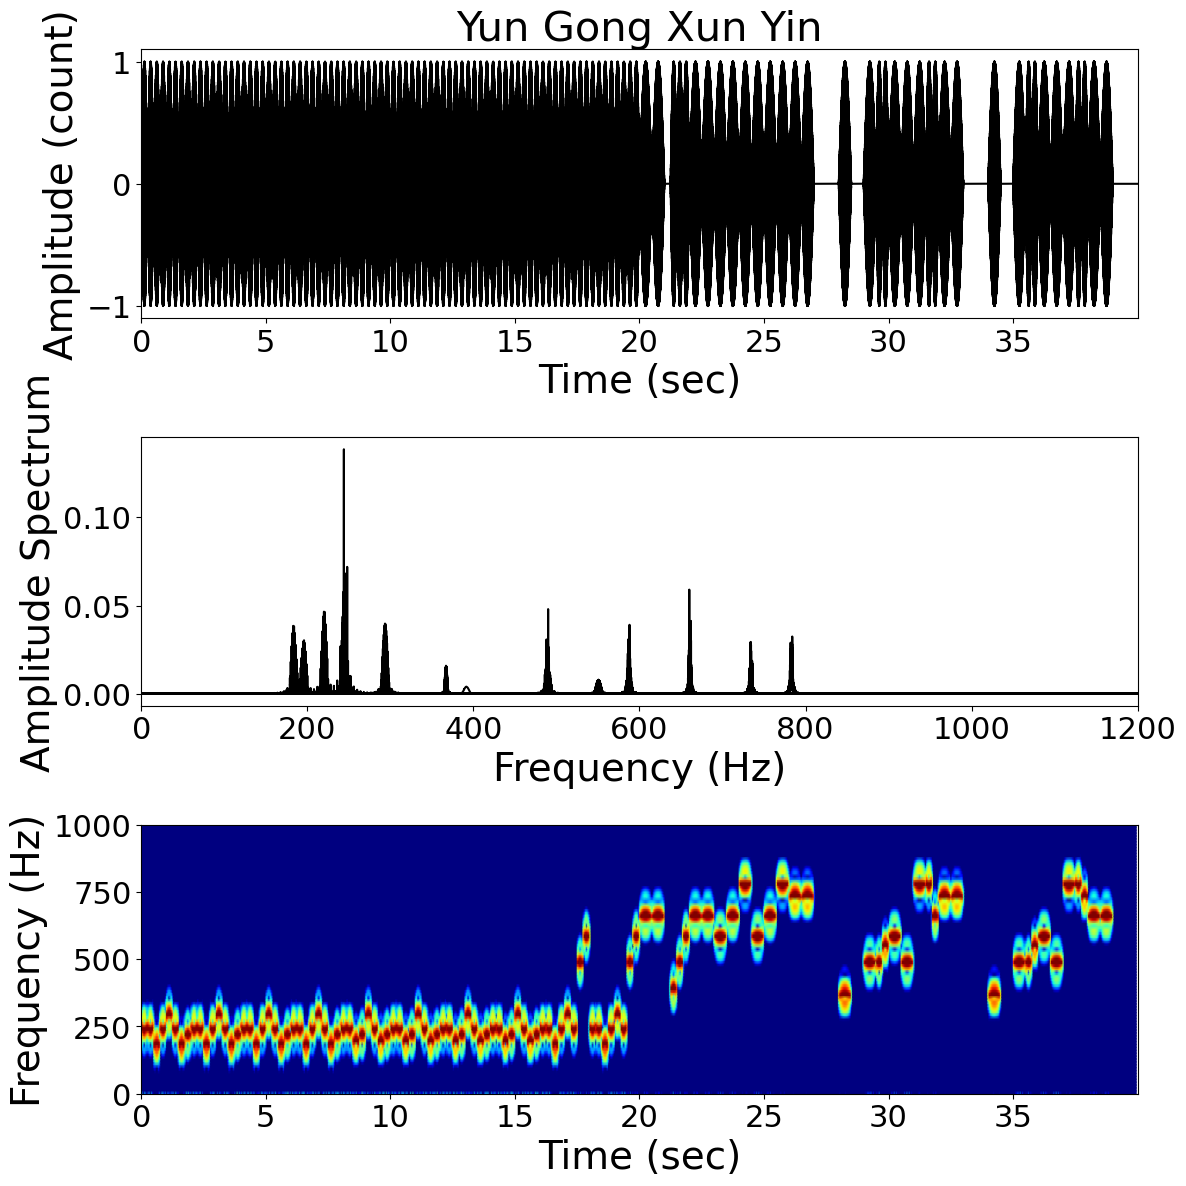

In [21]:
Y=np.fft.fft(y_ygxy)
N=len(y_ygxy)
t=T*np.arange(0,N,1)
f=Fs*np.arange(0,N//2+1,1)/N
P2 = np.abs(Y/N) 
P1 = P2[:N//2+1]
P1[1:]=2*P1[1:]

fig,axes=plt.subplots(3,1,figsize=(12,12))
# Time domain signal
axes[0].plot(t,y_ygxy,'k')
axes[0].set_xlim([0,t[-1]])
axes[0].set_xlabel('Time (sec)', fontsize=28)
axes[0].set_ylabel('Amplitude (count)', fontsize=28)
axes[0].set_title('Yun Gong Xun Yin',fontsize=30)
axes[0].tick_params(labelsize=22)
# Amplitude Spectrum
axes[1].plot(f,P1,'k')
axes[1].set_xlim([0,1200])
axes[1].set_xlabel('Frequency (Hz)', fontsize=28)
axes[1].set_ylabel('Amplitude Spectrum', fontsize=28)
axes[1].tick_params(labelsize=22)
# Spectrogram
f_spec, t_spec, Sxx=signal.spectrogram(y_ygxy,Fs,nperseg=4096,noverlap=2048,nfft=4096)
temp=np.log10(np.abs(Sxx)+1e-32)
im=axes[2].pcolormesh(t_spec,f_spec,temp,cmap='jet',vmin=np.min(temp)/5,vmax=np.max(temp)*2,shading='gouraud')
axes[2].set_ylabel('Frequency (Hz)',fontsize=28)
axes[2].set_xlabel('Time (sec)', fontsize=28)
axes[2].set_xlim([0,t[-1]])
axes[2].set_ylim([0,1000])
axes[2].tick_params(labelsize=22)
plt.tight_layout(pad=1.2, h_pad=1.8)
plt.savefig('./YunGongXunYin.png',dpi=300)
plt.show()


In [ ]:
print('Test git')